# Exercise 1 Clustering of programming languages
Last assignment, you were tasked to predict the programming language based on code snippets.
To get insights on what languages are similar, you will cluster the text data and visualize it
accordingly.  
### Tasks:
1. Load the embeddings (and if needed, the text dataset).
2. Research when an if dimensionality reduction before clustering for presentation in exercise. Preprocess your data according to your findings.
3. Cluster your data with KMEANS and DBSCAN.
4. Visualize and compare and interpret the results for the presentation in the exercise.
#### Deliverables: A notebook with your research, clustering, visualizations, analysis and interpretation.

### Imports

In [2]:
import pyarrow.feather as feather

In [3]:
# PCA
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# KMeans
from sklearn.cluster import KMeans

In [5]:
# DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

#### Load the embeddings

In [6]:
df = feather.read_table('embeddings.feather').to_pandas()
df.head(4)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X760,X761,X762,X763,X764,X765,X766,X767,X768,language
0,-0.173793,-0.325611,0.260916,-0.090371,-0.003099,-0.689703,0.169172,0.161007,-0.156974,-0.634382,...,-0.444923,-0.085975,-0.347440,-0.071519,0.916738,0.032165,-0.395401,-0.151372,0.753215,Markdown
1,-0.551476,0.114461,-0.156257,-0.095483,-0.491529,-0.717104,0.610803,-0.087726,0.567443,-0.527859,...,-0.543031,-0.006777,-0.379004,-0.076810,0.353173,-0.265057,-0.592026,-0.525372,0.525150,XML
2,-0.340610,0.312390,-0.245592,-0.390323,0.570317,-0.937024,0.177742,1.024876,0.044157,0.052844,...,-0.521548,0.697367,-0.445880,-0.071272,0.251338,0.437460,-0.264365,-0.438744,0.614954,Text
3,0.030533,-0.629911,-0.322072,0.253435,-0.335275,-0.971226,0.205228,0.110962,0.084097,-0.191846,...,-0.457321,0.029477,-0.645487,-0.347078,1.028343,-0.073201,-0.468006,-0.304346,0.600119,Markdown


#### Dimensionality Reduction 
*Source:* https://www.geeksforgeeks.org/machine-learning/dimensionality-reduction/  
Using too many features can cause slow computation and may lead to overfitting. To prevent this from happening, in many real world use cases like Text Categorization dimensionality reduction is applied to reduce the number of features while retaining as much information as possible. PCA is a common technique for this purpose, which transforms the original features into a new set of uncorrelated features called principal components. These components are ordered by the amount of variance they capture from the data, allowing us to select a subset of them that retain most of the information while reducing dimensionality.


#### Preprocessing - Dimensionality Reduction

In [7]:
X = df.drop(columns=['language'])
y = df['language']

In [8]:
# Standardize the data
scalter = StandardScaler()
X_scaled = scalter.fit_transform(X)

In [9]:
# Applying PCA
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

#### Cluster your data with KMEANS and DBSCAN

##### KMEANS

In [10]:
# cluster data
# Initialize and fit KMeans
kmeans = KMeans(n_clusters=10, random_state=0, n_init="auto")
kmeans.fit(X_pca)
kmeans_labels = kmeans.labels_


##### DBSCAN
*Source:* https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

Text(0.5, 1.0, 'K-distance Graph')

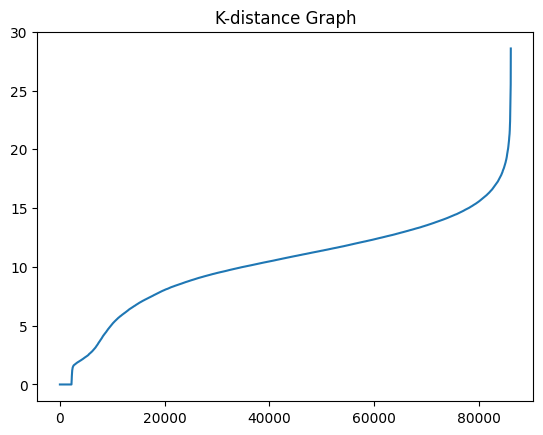

In [11]:
# get best parameters for DBSCAN
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances[:,4])
plt.plot(distances)
plt.title("K-distance Graph")


In [12]:
best_eps = 0.8
best_min_samples = 5

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan.fit_predict(X_pca)

print(f"Number of clusters: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Noise points: {np.sum(dbscan_labels == -1)}")

Number of clusters: 122
Noise points: 83843


#### Visualization

In [13]:
pca_viz = PCA(n_components=2, random_state=42)
X_pca_viz = pca_viz.fit_transform(X_scaled)

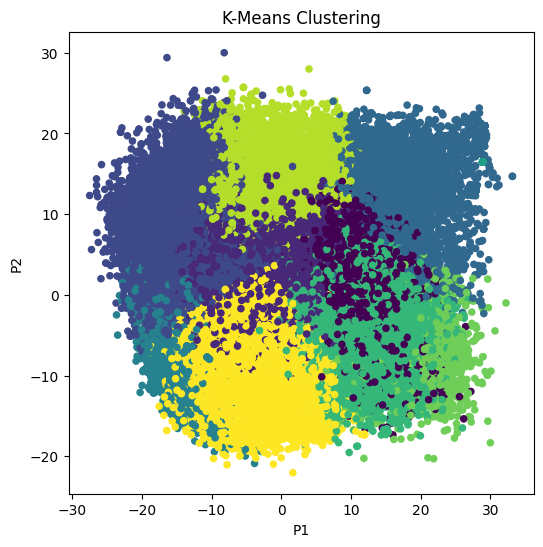

In [14]:
# KMeans
plt.figure(figsize=(6, 6))
plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], c=kmeans_labels, cmap='viridis', s=20)
plt.title('K-Means Clustering')
plt.xlabel('P1')
plt.ylabel('P2')
plt.show()

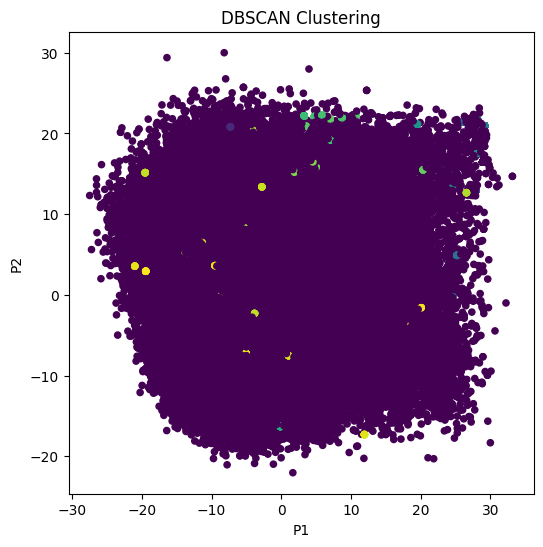

In [15]:
# DBSCAN
plt.figure(figsize=(6, 6))
plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], c=dbscan_labels, cmap='viridis', s=20)
plt.title('DBSCAN Clustering')
plt.xlabel('P1')
plt.ylabel('P2')
plt.show()

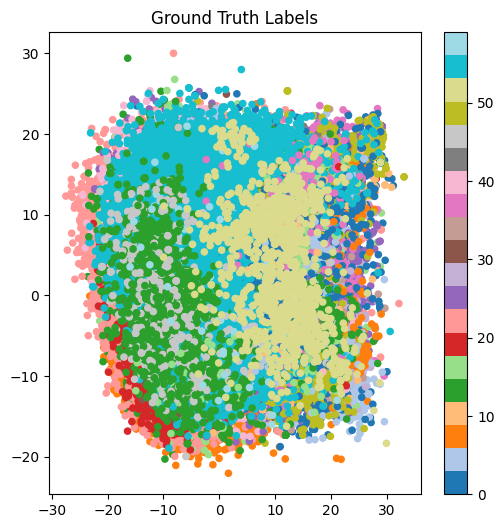

In [16]:
# Ground Truth
y_reset = y.reset_index(drop=True)

plt.figure(figsize=(6,6))
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], c=pd.factorize(y_reset)[0], cmap='tab20', s=20)
plt.title('Ground Truth Labels')
plt.colorbar(scatter)
plt.show()

In [17]:
from sklearn.metrics import silhouette_score

print(f"KMeans silhouette: {silhouette_score(X_pca, kmeans_labels):.3f}")
print(f"DBSCAN silhouette: {silhouette_score(X_pca, dbscan_labels):.3f}")

KMeans silhouette: 0.128
DBSCAN silhouette: -0.375


#### Interpretation
K-Means produces more or less natural clusters but they don't align well with the ground truth, since K-Means assumes more like round equally sized clusters which the data doesn't follow. DBSCAN fails almost entirely, classifying everything as one cluster. The ground truth confirms the core issue of the programming languages heavily overlaping. Therefor neither algorithm cancompletely separate them.

# Exercise 2 LDA on news content 
You perform topic modeling on the 20 Newsgroups dataset
using Latent Dirichlet Allocation (LDA). The goal is to discover latent topics in news articles
and analyze how well they align with known newsgroup categories.
### Steps:
1. Load the 20 Newsgroups dataset (full or selected categories)
2. Preprocess the text accordingly:
3. Train an LDA models with a varying numbers of topics.
4. Inspect and interpret topics using top-Nwords per topic
5. Assign dominant topics to documents
6. Visualize topic distributions using:  
• t-SNE, PCA or UMAP on document-topic vectors  
• pyLDAvis visualization  
#### Deliverables:
• Notebook with data loading, preprocessing, and LDA training  
• Discussion for the presentation:  
– How interpretable are the topics?  
– How does the number of topics affect results?  
– What are the limitations of LDA on real-world news data  

### Imports

In [18]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from nltk.stem import PorterStemmer

[nltk_data] Downloading package stopwords to C:\Users\Celina
[nltk_data]     Binder\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Celina
[nltk_data]     Binder\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Celina
[nltk_data]     Binder\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Celina
[nltk_data]     Binder\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [19]:
import re

import numpy as np
import matplotlib.pyplot as plt

In [20]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install pyLDAvis

Note: you may need to restart the kernel to use updated packages.


#### Load 20 Newsgroup dataset

In [22]:
from sklearn.datasets import fetch_20newsgroups


In [23]:
#get categories from newsgroups
newsgroups_train = fetch_20newsgroups(subset='train')
cats = newsgroups_train.target_names
cats

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

#### Preprocess
- The Dataset is One - Dimensional 
- has 20 Classes

**AI Use:** Claude Sonnet 4.6  
*Prompt:* how can I remove the Metadata from a dataset and is it even necessary for the 20newsgroup one?

In [24]:
# removing Metadata - without it LDA cheats, as it would just cluster by metadata
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
texts = newsgroups.data

*Source:* https://www.geeksforgeeks.org/nlp/topic-modeling-using-latent-dirichlet-allocation-lda/

In [25]:
# clean raw text data
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)        # remove emails
    text = re.sub(r'http\S+', '', text)         # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)        # remove numbers/punctuation
    text = re.sub(r'\s+', ' ', text).strip()    # normalize whitespace
    return text

texts_clean = [clean_text(t) for t in texts]

*Source:* 
- https://www.geeksforgeeks.org/python/python-lemmatization-with-nltk/  
- https://www.geeksforgeeks.org/machine-learning/python-stemming-words-with-nltk/

In [26]:
# Download NLTK stopwords
import gensim


nltk.download('stopwords')
stop_words = stopwords.words('english')

# Tokenize and remove stopwords
def tokenize(text):
    tokens = gensim.utils.simple_preprocess(text, deacc=True)
    tokens = [token for token in tokens if token not in stop_words]
    return tokens

texts_tokenized = [tokenize(t) for t in texts_clean]

[nltk_data] Downloading package stopwords to C:\Users\Celina
[nltk_data]     Binder\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
# Lemmatization
import spacy

# Load spaCy model
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def lemmatize(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc]

texts_lemmatized = [lemmatize(tokens) for tokens in texts_tokenized]

In [28]:
# Tokenization with nltk
import nltk

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

stemmer = PorterStemmer()

def preprocess_stem(text):
    tokens = word_tokenize(text.lower())
    return [
        stemmer.stem(token)
        for token in tokens
        if token.isalpha()
        and token not in stop_words
        and len(token) > 2
    ]

In [29]:
import gensim.corpora as corpora

# Create dictionary and corpus
id2word = corpora.Dictionary(texts_lemmatized)
corpus = [id2word.doc2bow(text) for text in texts_lemmatized]

#### Train an LDA models with a varying numbers of topics

In [30]:
topic_counts = [5, 10, 20, 30]
lda_models = {}

for n in topic_counts:
    print(f"Training LDA with {n} topics...")
    lda_models[n] = gensim.models.ldamodel.LdaModel(
        corpus=corpus,
        id2word=id2word,
        num_topics=n,
        random_state=100,
        update_every=1,
        chunksize=100,
        passes=10,
        alpha='auto',
    )

# pick best model for further steps
best_lda = lda_models[20]

Training LDA with 5 topics...
Training LDA with 10 topics...
Training LDA with 20 topics...
Training LDA with 30 topics...


#### Inspect and interpret topics using top-Nwords per topic
*Source:* https://stackoverflow.com/q/61705598

In [31]:
import pandas as pd

def topics_to_df(model, n=10):
    topic_dict = {}
    for i in range(model.num_topics):
        top_words = [word for word, prob in model.show_topic(i, topn=n)]
        topic_dict[f"Topic {i}"] = top_words
    return pd.DataFrame(topic_dict)

topics_to_df(best_lda, n=10)

,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19
0,university,people,use,health,key,space,board,new,window,game,bob,sort,earth,image,fire,please,not,wire,god,moon
1,gun,say,system,patient,card,cost,pin,power,drive,team,la,win,entire,previous,circuit,email,do,science,bible,mass
2,weapon,one,include,medical,driver,center,replace,public,version,play,dog,he,proof,poster,tank,send,get,text,christ,share
3,country,we,also,clearly,chip,graphic,step,source,computer,player,smith,series,south,shift,gas,list,would,ground,faith,vehicle
4,war,believe,program,doctor,disk,screen,amount,happen,run,pc,ron,vs,pitch,heavy,dan,mail,know,eg,psalm,clinton
5,president,many,file,cold,mac,development,slow,government,machine,st,brian,generally,oil,detailed,contribution,address,like,noise,greek,objective
6,kill,mean,information,temperature,price,friend,external,order,server,season,att,advantage,insurance,december,bds,thank,I,straight,revelation,recall
7,state,make,number,motorcycle,sale,currently,com,small,reply,fan,definitely,al,lunar,cult,destruction,post,one,cover,effective,ed
8,city,may,may,medicine,mode,solution,greatly,press,info,hockey,pit,blue,tech,violence,suicide,newsgroup,go,flight,love,trick
9,attack,right,support,pain,mb,mouse,across,next,tape,league,jr,detroit,brief,yellow,wonderful,advance,well,shell,sequence,van


In [32]:
for n, model in lda_models.items():
    print(f"\n=== {n} Topics ===")
    display(topics_to_df(model, n=10))


=== 5 Topics ===


,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4
0,government,people,not,game,use
1,key,god,get,team,program
2,public,say,do,play,file
3,report,one,would,player,system
4,gun,not,I,year,image
5,national,would,one,season,include
6,state,make,like,st,window
7,weapon,believe,know,hockey,available
8,law,many,use,win,datum
9,press,think,go,hit,software



=== 10 Topics ===


,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9
0,government,people,use,god,drive,image,card,game,file,not
1,state,say,also,happen,key,space,mac,team,window,do
2,report,one,include,christ,chip,center,mb,play,run,get
3,law,believe,system,fire,earth,analysis,board,player,program,would
4,public,many,information,server,system,orbit,video,st,version,one
5,mr,man,new,ground,disk,mission,wire,season,sort,know
6,country,would,may,hit,network,launch,port,win,application,like
7,people,claim,please,psalm,driver,environment,pin,league,ftp,I
8,kill,word,send,greek,technology,moon,cpu,office,format,go
9,gun,mean,support,nature,phone,development,modem,division,source,well



=== 20 Topics ===


,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19
0,university,people,use,health,key,space,board,new,window,game,bob,sort,earth,image,fire,please,not,wire,god,moon
1,gun,say,system,patient,card,cost,pin,power,drive,team,la,win,entire,previous,circuit,email,do,science,bible,mass
2,weapon,one,include,medical,driver,center,replace,public,version,play,dog,he,proof,poster,tank,send,get,text,christ,share
3,country,we,also,clearly,chip,graphic,step,source,computer,player,smith,series,south,shift,gas,list,would,ground,faith,vehicle
4,war,believe,program,doctor,disk,screen,amount,happen,run,pc,ron,vs,pitch,heavy,dan,mail,know,eg,psalm,clinton
5,president,many,file,cold,mac,development,slow,government,machine,st,brian,generally,oil,detailed,contribution,address,like,noise,greek,objective
6,kill,mean,information,temperature,price,friend,external,order,server,season,att,advantage,insurance,december,bds,thank,I,straight,revelation,recall
7,state,make,number,motorcycle,sale,currently,com,small,reply,fan,definitely,al,lunar,cult,destruction,post,one,cover,effective,ed
8,city,may,may,medicine,mode,solution,greatly,press,info,hockey,pit,blue,tech,violence,suicide,newsgroup,go,flight,love,trick
9,attack,right,support,pain,mb,mouse,across,next,tape,league,jr,detroit,brief,yellow,wonderful,advance,well,shell,sequence,van



=== 30 Topics ===


,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,...,Topic 20,Topic 21,Topic 22,Topic 23,Topic 24,Topic 25,Topic 26,Topic 27,Topic 28,Topic 29
0,war,people,use,drive,card,service,machine,company,run,not,...,program,subject,law,object,image,role,please,church,road,key
1,kill,say,also,tape,driver,cover,mac,technology,computer,do,...,file,box,government,proposal,bit,paragraph,thank,jesus,archive,chip
2,april,one,system,cable,mode,model,board,black,cost,would,...,window,port,weapon,union,software,influence,send,signal,six,obtain
3,armenian,we,new,utility,video,clear,graphic,wire,display,get,...,disk,cheap,right,testimony,version,sea,email,sunday,five,clipper
4,hit,believe,problem,muslim,monitor,describe,mb,encryption,copy,know,...,access,appreciate,firearm,definate,available,wolf,mail,creator,baby,generally
5,bank,mean,may,observation,controller,text,currently,extra,fast,like,...,server,pin,citizen,crum,application,stretch,address,friday,art,germany
6,attack,many,include,cold,printer,suppose,digital,unit,memory,well,...,scsi,office,state,recepticle,support,china,interested,chastity,wave,advantage
7,city,question,number,modern,bus,safety,replace,market,current,go,...,ms,eg,peace,paroxysmal,color,ryan,phone,bc,useless,secret
8,vs,reason,need,responsibility,south,series,hard,energy,info,think,...,share,serial,court,millie,code,criticize,advance,bake,archivename,ed
9,commit,make,work,essentially,vga,input,step,ticket,speed,one,...,transfer,connect,federal,intracranial,sort,fascist,screen,lutheran,bosnian,motorcycle


#### Assign dominant topics to documents  

**AI Use:** Claude Sonnet 4.6  
*Prompt:* the next step is to use t-SNE, PCA or UMAP (i want to do all of them) and pyLDAvis visualization so what would be used for assigning dominant topics to documents?

In [33]:
# get full topic distribution for every document (not just dominant topic)
def get_doc_topic_matrix(lda_model, corpus):
    doc_topic_matrix = np.zeros((len(corpus), lda_model.num_topics))
    
    for i, doc_bow in enumerate(corpus):
        topic_dist = lda_model.get_document_topics(doc_bow, minimum_probability=0)
        for topic_id, prob in topic_dist:
            doc_topic_matrix[i, topic_id] = prob
    
    return doc_topic_matrix

doc_topic_matrix = get_doc_topic_matrix(best_lda, corpus)
# shape should be (18846, 20) — one row per doc, one col per topic
print(doc_topic_matrix.shape)

(18846, 20)


In [34]:
# get dominant topic per document (index of highest probability topic)
dominant_topics = np.argmax(doc_topic_matrix, axis=1)
print(dominant_topics.shape)

df_docs = pd.DataFrame({
    'document_preview': [t[:80] + '...' for t in texts],
    'dominant_topic': dominant_topics,
    'true_category': [newsgroups.target_names[i] for i in newsgroups.target]
})
display(df_docs.head(20))

(18846,)


,document_preview,dominant_topic,true_category
0,\n\nI am sure some bashers of Pens fans are pr...,9,rec.sport.hockey
1,My brother is in the market for a high-perform...,4,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,0,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,2,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,16,comp.sys.mac.hardware
5,\n\nBack in high school I worked as a lab assi...,2,sci.electronics
6,\n\nAE is in Dallas...try 214/241-6060 or 214/...,16,comp.sys.mac.hardware
7,"\n[stuff deleted]\n\nOk, here's the solution t...",16,rec.sport.hockey
8,"\n\n\nYeah, it's the second one. And I believ...",16,rec.sport.hockey
9,\nIf a Christian means someone who believes in...,1,talk.religion.misc


#### Visualize topic distributions using:  
• t-SNE, PCA or UMAP on document-topic vectors  
• pyLDAvis visualization

##### **PCA**

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(doc_topic_matrix)

##### **t-SNE**

In [36]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=40)
X_tsne = tsne.fit_transform(doc_topic_matrix)

##### **UMAP**

In [36]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(doc_topic_matrix)

c:\Users\Celina Binder\OneDrive - FH OOe\Desktop\FH Hagenberg\4_Semester_FH_Hagenberg\NLP4IL\NLP4IL.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


**AI Use:** Claude Sonnet 4.6  
*Prompt:* with the PCA, UMAP and tsne already computed tell me how do make a visualization to plot the three plots next to eachother

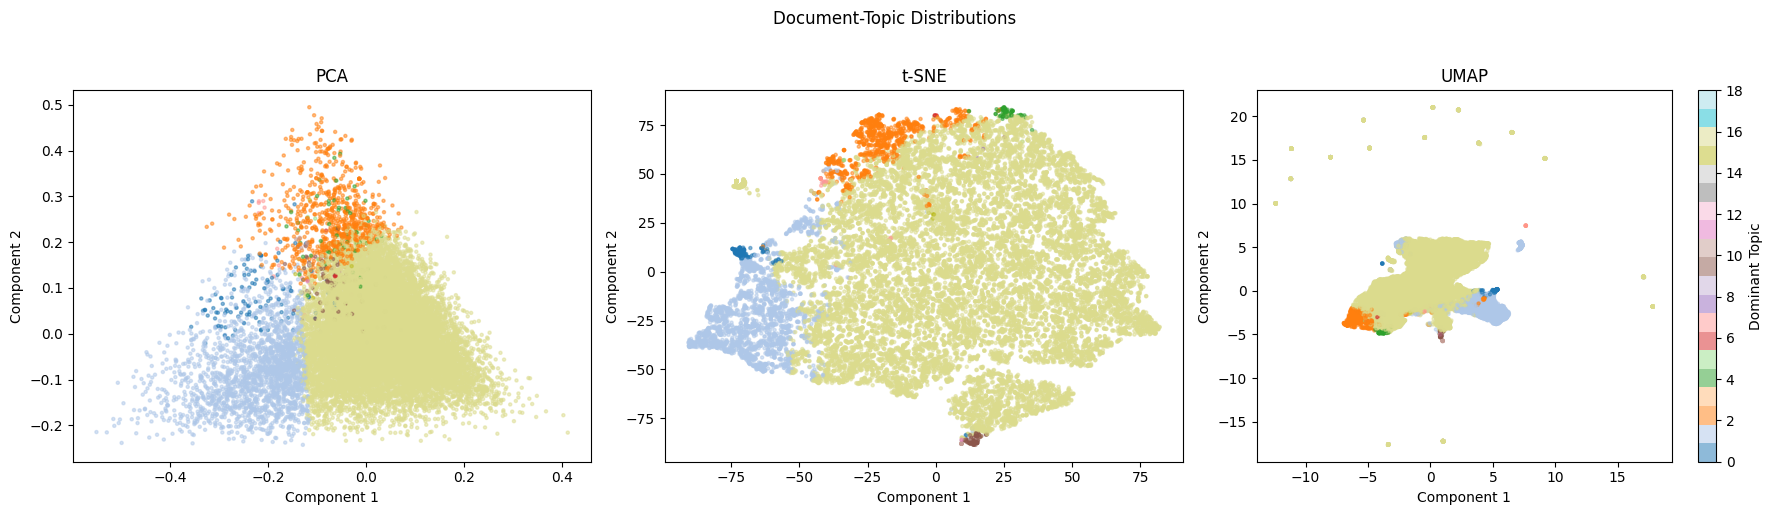

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, X_reduced, title in zip(
    axes,
    [X_pca, X_tsne, X_umap],
    ['PCA', 't-SNE', 'UMAP']
):
    scatter = ax.scatter(
        X_reduced[:, 0], X_reduced[:, 1],
        c=dominant_topics,
        cmap='tab20',
        s=5,
        alpha=0.5
    )
    ax.set_title(title)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')

plt.colorbar(scatter, ax=axes[-1], label='Dominant Topic')
plt.suptitle('Document-Topic Distributions', y=1.02)
plt.tight_layout()
plt.show()

In [40]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()

vis = gensimvis.prepare(best_lda, corpus, id2word)
pyLDAvis.display(vis)


In [41]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()

vis = gensimvis.prepare(best_lda, corpus, id2word)
pyLDAvis.display(vis)

**AI Use:** Claude Sonnet 4.6  
*Prompt:* give me a nice comparison plot for this code

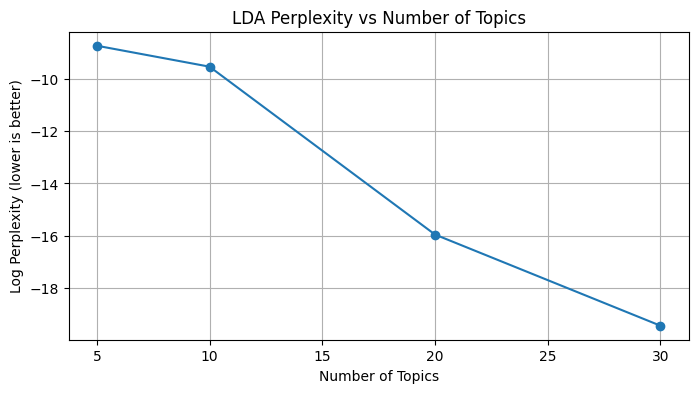

In [56]:
import matplotlib.pyplot as plt

log_likelihoods = {n: model.log_perplexity(corpus) for n, model in lda_models.items()}

plt.figure(figsize=(8, 4))
plt.plot(list(log_likelihoods.keys()), list(log_likelihoods.values()), marker='o')
plt.xlabel('Number of Topics')
plt.ylabel('Log Perplexity (lower is better)')
plt.title('LDA Perplexity vs Number of Topics')
plt.grid(True)
plt.show()

##### How interpretable are the topics?
With 20 topics the results are quite interpretable, some topics correspond to real newsgroup categories like space, religion, or politics based on their top words. However many topics contain overlapping or generic words making them hard to label with a high confidence. LDA works better here than on random text because the newsgroup categories are fairly distinct domains.

##### How does the number of topics affect results?
With 5 topics the model is too coarse, quite different newsgroups get merged into the same topic. At 20 topics, which matches the actual number of categories, the topics become more specific and meaningful. At 30 topics some topics become too narrow to interpret. The plots shows that more topics always improve the score technically, but interpretability is best at around 20 before it gets worse again.

##### What are the limitations of LDA on real-world news data?
LDA assumes each document is a mixture of topics and that word order doesn't matter (bag-of-words), which loses a lot of context. News posts are often short, noisy, and written informally which makes topic separation harder. LDA also struggles when topics share vocabulary, for example politics and religion newsgroups both use similar words. Also LDA has no understanding of word meaning, so synonyms or related terms are treated as completely separate features.

# Exercise 3 BERTopic on Song lyrics
In this exercise, you will cluster Song lyrics with BERTopic. The music lyrics are usually
very specific to a particular topic (think Christmas, Lovesongs, ...), is this also reflected in the
resulting clusters?
### Steps:
1. Load the lyrics and process them with BERTopic.
2. Tune the hyperparamters (UMAP and HDBScan) to get meaningful clusters.
3. Validate the clusters by taking a look at some samples of the clusters.
4. Prepare the build-in visualizations of BERTopic for presentation in the exercise.
#### Deliverables:
• Notebook containing the BERTopic modeling and vis.  
• Presentation of the hyper parameter tuning  

### Imports


In [57]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [58]:
pip install bertopic

Note: you may need to restart the kernel to use updated packages.


In [4]:
import shutil
import os
import pandas as pd

In [8]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

In [62]:
!pip install --no-deps bertopic
!pip install --upgrade numpy pandas scikit-learn tqdm pyyaml

In [63]:
pip install model2vec umap-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import numpy as np

#### Load the lyrics

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("notshrirang/spotify-million-song-dataset")

**AI Use:** Claude Sonnet 4.6  
*Prompt:* how can I find and move an already downloaded dataset into a different folder

In [ ]:
# find the csv file and move it into my folder for Assignment 5
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]

shutil.copy(os.path.join(path, csv_file), "./spotify_songs.csv")
print("Saved to ./spotify_songs.csv")

Saved to ./spotify_songs.csv


In [5]:
# Load data
df = pd.read_csv("./spotify_songs.csv")
print(df.columns)   # get an overview of the columns in the dataset
print(df.head(2))

Index(['artist', 'song', 'link', 'text'], dtype='str')
  artist                   song                                        link  \
0   ABBA  Ahe's My Kind Of Girl  /a/abba/ahes+my+kind+of+girl_20598417.html   
1   ABBA       Andante, Andante       /a/abba/andante+andante_20002708.html   

                                                text  
0  Look at her face, it's a wonderful face  \r\nA...  
1  Take it easy with me, please  \r\nTouch me gen...  


#### Preprocessing with BERTopic
**BERTopic handles automatically:**

Tokenization → sentence transformer  
Semantic meaning / embeddings → all-MiniLM-L6-v2  
Dimensionality reduction → UMAP  
Clustering → HDBSCAN  
Topic word extraction → CountVectorizer + c-TF-IDF  

**AI Use:** Claude  
*Prompt:* give me nice arrows for this text: Tokenization -> sentence transformer  
Semantic meaning/embeddings -> all-MiniLM-L6-v2  
Dimensionality reduction -> UMAP  
Clustering -> HDBSCAN  
Topic word extraction -> CountVectorizer + c-TF-IDF  


*Source:* https://bertopic.com/

In [6]:
# clean data: drop rows with missing lyrics
docs = df['text'].dropna().tolist()

##### initialize models

In [9]:
vectorizer_model = CountVectorizer(
    stop_words="english", 
    min_df=2, 
    ngram_range=(1, 2))

In [10]:
umap_model = UMAP(
    n_neighbors=15, 
    n_components=5, 
    min_dist=0.0, 
    metric='cosine', 
    random_state=42)

In [11]:
hdbscan_model = HDBSCAN(
    min_cluster_size=50, 
    min_samples=10, 
    prediction_data=True)

In [12]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
# Build BERTopic Model
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    verbose=True
)

**AI Use:** Claude Sonnet 4.6  
*Prompt:* tell me how to make tuning faster and write me a function to evaluate different configs that I defined already

In [16]:
# precompute embeddings for all documents
embeddings = embedding_model.encode(docs, show_progress_bar=True)
topics, probs = topic_model.fit_transform(docs, embeddings)

Batches:   0%|          | 0/1802 [00:00<?, ?it/s]

2026-04-20 15:01:27,934 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-20 15:02:51,862 - BERTopic - Dimensionality - Completed ✓
2026-04-20 15:02:51,864 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-20 15:03:00,384 - BERTopic - Cluster - Completed ✓
2026-04-20 15:03:00,403 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-20 15:03:14,929 - BERTopic - Representation - Completed ✓


#### Hyperparameter Tuning

In [17]:
# different configs
configs = [
    {"n_neighbors": 15, "n_components": 5, "min_cluster_size": 50},
    {"n_neighbors": 10, "n_components": 5, "min_cluster_size": 30},
    {"n_neighbors": 20, "n_components": 10, "min_cluster_size": 100},
    {"n_neighbors": 25, "n_components": 10, "min_cluster_size": 80},
]

In [18]:
for cfg in configs:
    umap_model = UMAP(n_neighbors=cfg["n_neighbors"], n_components=cfg["n_components"], 
                      min_dist=0.0, metric='cosine', random_state=42)
    hdbscan_model = HDBSCAN(min_cluster_size=cfg["min_cluster_size"], 
                             min_samples=10, prediction_data=True)
    
    m = BERTopic(umap_model=umap_model, hdbscan_model=hdbscan_model,
                 vectorizer_model=vectorizer_model, verbose=False)
    t, _ = m.fit_transform(docs, embeddings)
    
    n_topics = len(set(t)) - 1  # exclude -1 outliers
    n_outliers = sum(1 for x in t if x == -1)
    print(f"Config {cfg} -> Topics: {n_topics}, Outliers: {n_outliers}")

Config {'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 50} -> Topics: 6, Outliers: 311
Config {'n_neighbors': 10, 'n_components': 5, 'min_cluster_size': 30} -> Topics: 12, Outliers: 785
Config {'n_neighbors': 20, 'n_components': 10, 'min_cluster_size': 100} -> Topics: 5, Outliers: 176
Config {'n_neighbors': 25, 'n_components': 10, 'min_cluster_size': 80} -> Topics: 4, Outliers: 261


**AI Use:** Claude Sonnet 4.6
*Prompt:* give me the code for one cell to present the hyperparameter tuning

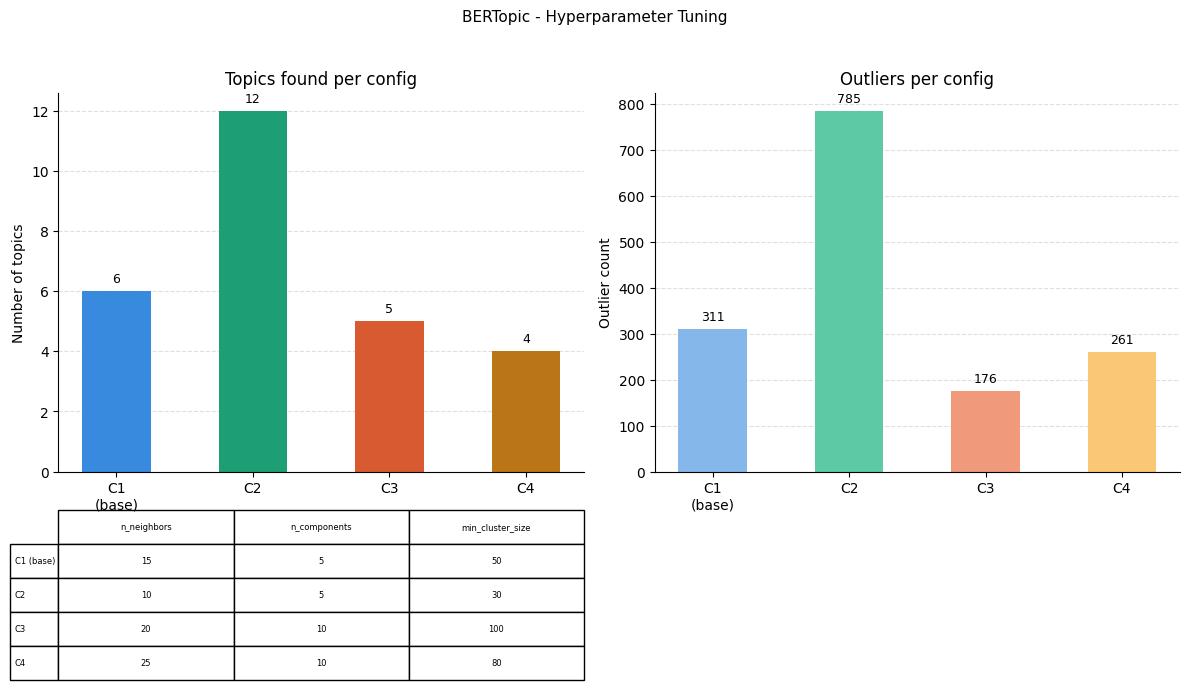

In [24]:
# Hyperparameter Tuning Visualization

# results from the tuning loop above
labels   = ["C1\n(base)", "C2", "C3", "C4"]
topics   = [6, 12, 5, 4]       # replace with your actual printed values
outliers = [311, 785, 176, 261]  # replace with your actual printed values

x        = np.arange(len(labels))
colors_t = ["#378ADD", "#1D9E75", "#D85A30", "#BA7517"]
colors_o = ["#85B7EB", "#5DCAA5", "#F0997B", "#FAC775"]

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

for ax, vals, colors, ylabel, title in zip(
    axes,
    [topics, outliers],
    [colors_t, colors_o],
    ["Number of topics", "Outlier count"],
    ["Topics found per config", "Outliers per config"],
):
    bars = ax.bar(x, vals, color=colors, width=0.5, zorder=2)
    ax.bar_label(bars, labels=[f"{v:,}" for v in vals], padding=4, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

table = axes[0].table(
    cellText=[
        ["15", "5",  "50"],
        ["10", "5",  "30"],
        ["20", "10", "100"],
        ["25", "10", "80"],
    ],
    rowLabels=["C1 (base)", "C2", "C3", "C4"],
    colLabels=["n_neighbors", "n_components", "min_cluster_size"],
    cellLoc="center", loc="bottom", bbox=[0, -0.55, 1, 0.45]
)
table.auto_set_font_size(False)
table.set_fontsize(6)

plt.suptitle("BERTopic - Hyperparameter Tuning", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

#### Validate the clusters by taking a look at some samples of the clusters.

In [ ]:
# look at topic info
topic_info = topic_model.get_topic_info()
display(topic_info.head(20))

# inspect top words per topic
for topic_id in topic_info['Topic'].values[:10]:  # first 10 topics
    if topic_id == -1:
        continue
    words = topic_model.get_topic(topic_id)
    print(f"\nTopic {topic_id}: {[w for w, _ in words]}")

# look at sample documents per topic
for topic_id in [0, 1, 2, 3, 4]:
    docs_in_topic = [docs[i] for i, t in enumerate(topics) if t == topic_id]
    print(f"\n--- Topic {topic_id} samples ---")
    for doc in docs_in_topic[:2]:   # 2 samples per topic
        print(f"  {doc[:200]}\n")

,Topic,Count,Name,Representation,Representative_Docs
0,-1,311,-1_pum_pum pum_pa_rum,"[pum, pum pum, pa, rum, nah, nah nah, rum pum,...","[Come they told me, pa rum pum pum pum \r\nA ..."
1,0,56121,0_love_don_know_just,"[love, don, know, just, like, oh, ll, got, ve,...",[Baby can you understand me now \r\nSometimes...
2,1,913,1_christmas_santa_merry_la,"[christmas, santa, merry, la, la la, year, bel...",[It's Christmas in Ignace \r\nMommy's got a r...
3,2,139,2_ang_sa_ko_na,"[ang, sa, ko, na, ng, ka, mo, di, lang, pa]","[Noon, iwanan mo ko \r\nHinihintay kong marin..."
4,3,57,3_je_le_tu_ich,"[je, le, tu, ich, les, que, und, est, pas, der]",[(Heaven's What I Feel - French Version) \r\n...
5,4,57,4_hai_mein_ke_dil,"[hai, mein, ke, dil, ki, se, od, hare, mustaph...",[Muze tum mil gaye humadam sahaaraa ho to ayes...
6,5,52,5_ni_wo_wa_ga,"[ni, wo, wa, ga, mo, love, yo, nae, anata, nai]","[I could not look back, \r\nYou'd gone away f..."



Topic 0: ['love', 'don', 'know', 'just', 'like', 'oh', 'll', 'got', 've', 'time']

Topic 1: ['christmas', 'santa', 'merry', 'la', 'la la', 'year', 'bells', 'jingle', 'claus', 'merry christmas']

Topic 2: ['ang', 'sa', 'ko', 'na', 'ng', 'ka', 'mo', 'di', 'lang', 'pa']

Topic 3: ['je', 'le', 'tu', 'ich', 'les', 'que', 'und', 'est', 'pas', 'der']

Topic 4: ['hai', 'mein', 'ke', 'dil', 'ki', 'se', 'od', 'hare', 'mustapha', 'ho']

Topic 5: ['ni', 'wo', 'wa', 'ga', 'mo', 'love', 'yo', 'nae', 'anata', 'nai']

--- Topic 0 samples ---
  Look at her face, it's a wonderful face  
And it means something special to me  
Look at the way that she smiles when she sees me  
How lucky can one fellow be?  
  
She's just my kind of girl, s

  Take it easy with me, please  
Touch me gently like a summer evening breeze  
Take your time, make it slow  
Andante, Andante  
Just let the feeling grow  
  
Make your fingers soft and light  


--- Topic 1 samples ---
  We wish you a merry Christmas  
We wish you 

#### Prepare the build-in visualizations of BERTopic for presentation in the exercise.
*Source:* https://deepwiki.com/MaartenGr/BERTopic/5-visualization

In [86]:
# Topic overview
topic_model.visualize_topics()

In [ ]:
# Top words per topic as bar charts
topic_model.visualize_barchart(top_n_topics=6)

In [88]:
# Topic hierarchy
topic_model.visualize_hierarchy()

In [89]:
# Similarity Heatmap
topic_model.visualize_heatmap()

In [85]:
reduced_embeddings = UMAP(n_neighbors=15, n_components=2, 
                          min_dist=0.0, metric='cosine', 
                          random_state=42).fit_transform(embeddings)

topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings,
                                hide_document_hover=True)  # hover=True is slow for large datasets